# Treinamento e revisão do Prophet

Previsão do fechamento do dia seguinte. Funções de cálculo: `trainer/evaluation.py`. A seleção usa três blocos cronológicos anteriores aos 147 dias finais. Esse período final já foi consultado em experimentos anteriores, portanto a comparação é retrospectiva.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import hashlib
import json
import logging
import platform
import sys
import matplotlib.pyplot as plt
import pandas as pd
import prophet
from prophet.serialize import model_to_json

ROOT = Path.cwd().parent if Path.cwd().name == "notebook" else Path.cwd()
sys.path.insert(0, str(ROOT))
from trainer.evaluation import load_series, candidates, validation_blocks, evaluate, metrics, fit_model, forecast_price

ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
log = logging.getLogger("training")
log.setLevel(logging.INFO)
log.handlers.clear()
handler = logging.FileHandler(ARTIFACTS / "training.log", mode="w", encoding="utf-8")
handler.setFormatter(logging.Formatter("%(asctime)s %(levelname)s %(message)s"))
log.addHandler(handler)
log.addHandler(logging.StreamHandler(sys.stdout))
log.info("Inicio UTC: %s; Python %s; Prophet %s", datetime.now(timezone.utc).isoformat(), platform.python_version(), prophet.__version__)


/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Inicio UTC: 2026-10-05T19:56:37.496983+00:00; Python 3.11.17; Prophet 1.2.2


## 1. Conferir os dados

Exijo os 731 dias completos de 2024 e 2025, sem lacunas, duplicatas ou preços inválidos. A fonte e o hash identificam a base usada.


In [2]:
data_path = ROOT / "data/btc_usd_2024_2025.csv"
series = load_series(data_path)
source = json.loads((ROOT / "data/data_source.json").read_text(encoding="utf-8"))
data_hash = hashlib.sha256(data_path.read_bytes()).hexdigest()
symbol = "BTCUSDT" if "BTCUSDT" in source["source"] else "BTC-USD"
quote = "USDT" if symbol == "BTCUSDT" else "USD"
log.info("Dados: %s; %s a %s; %d registros; SHA256 %s", source["source"], series.ds.min().date(), series.ds.max().date(), len(series), data_hash)
display(series.head())


Dados: CryptoDataDownload / Binance BTCUSDT (fallback usado após limite de requisições do Yahoo Finance); 2024-01-01 a 2025-12-31; 731 registros; SHA256 396adba8f048a12b3cd984df141d4addbb43808b4b9dfef3263825e1a3630396


,ds,y
0,2024-01-01,44179.55
1,2024-01-02,44946.91
2,2024-01-03,42845.23
3,2024-01-04,44151.10
4,2024-01-05,44145.11


## 2. Escolher a configuração

Comparo 19 configurações: a original, janelas de preço de 7 a 180 dias com duas flexibilidades de tendência e retornos logarítmicos com tendência constante e sazonalidade semanal opcional. São três blocos de 30 previsões diárias. Escolho pelo MAE médio desses 90 dias. Cada ajuste usa somente dados anteriores à previsão.


In [3]:
specs = candidates()
validation_rows = []
blocks = validation_blocks()
for spec in specs:
    frames = []
    for index, positions in enumerate(blocks, start=1):
        frame = evaluate(series, positions, spec)
        frames.append(frame)
        validation_rows.append({"config": spec["name"], "block": index, **metrics(frame)})
    log.info("Validacao %s: %s", spec["name"], metrics(pd.concat(frames)))
validation = pd.DataFrame(validation_rows)
validation.to_csv(ARTIFACTS / "validation_results.csv", index=False)
ranking = validation.groupby("config")[["mae_usdt", "mape_percent", "rmse_usdt"]].mean().sort_values("mae_usdt")
selected = next(spec for spec in specs if spec["name"] == ranking.index[0])
log.info("Escolha pela validacao: %s", json.dumps(selected))
display(ranking.round(2))


19:56:37 - cmdstanpy - INFO - Chain [1] start processing


19:56:37 - cmdstanpy - INFO - Chain [1] done processing


19:56:37 - cmdstanpy - INFO - Chain [1] start processing


19:56:37 - cmdstanpy - INFO - Chain [1] done processing


19:56:37 - cmdstanpy - INFO - Chain [1] start processing


...

19:58:33 - cmdstanpy - INFO - Chain [1] start processing


19:58:33 - cmdstanpy - INFO - Chain [1] done processing


Validacao retorno_todo_semanalTrue: {'mae_usdt': 1461.230822565668, 'mape_percent': 1.50400540400801, 'rmse_usdt': 2051.173522850085}


Escolha pela validacao: {"name": "retorno_todo_semanalTrue", "window": null, "target": "log_return", "params": {"growth": "flat", "daily_seasonality": false, "weekly_seasonality": true, "yearly_seasonality": false}}


,mae_usdt,mape_percent,rmse_usdt
config,,,
retorno_todo_semanalTrue,1461.23,1.50,2024.53
retorno_180_semanalTrue,1467.57,1.52,2004.84
retorno_180_semanalFalse,1480.67,1.53,2020.55
retorno_todo_semanalFalse,1482.50,1.53,2018.76
retorno_90_semanalTrue,1516.16,1.57,2073.74
retorno_90_semanalFalse,1518.48,1.57,2038.93
preco_30d_cp0.5,1873.18,1.90,2442.53
preco_60d_cp0.5,1972.60,2.03,2522.97
preco_7d_cp0.05,2020.85,2.08,2510.57


## 3. Avaliar os mesmos 147 dias finais

Para cada data, ajusto com o passado, prevejo o dia seguinte e só então incorporo o fechamento real. Comparo com o Prophet original e com repetir o fechamento anterior. A API representa um único corte desse processo: novas datas exigem atualizar os dados e treinar novamente. O teste final já foi examinado antes; dados novos seriam necessários para confirmar a generalização.


19:58:33 - cmdstanpy - INFO - Chain [1] start processing


19:58:33 - cmdstanpy - INFO - Chain [1] done processing


19:58:33 - cmdstanpy - INFO - Chain [1] start processing


19:58:33 - cmdstanpy - INFO - Chain [1] done processing


19:58:33 - cmdstanpy - INFO - Chain [1] start processing


...

Teste selected: {'mae_usdt': 1604.1041261845571, 'mape_percent': 1.5387211000679544, 'rmse_usdt': 2127.6249459573446}


Teste original: {'mae_usdt': 6878.2534558415155, 'mape_percent': 6.8665076108064955, 'rmse_usdt': 8930.144285348197}


Teste baseline: {'mae_usdt': 1593.6343537414966, 'mape_percent': 1.523538714002367, 'rmse_usdt': 2112.4280428433904}


Configuracao a exportar: retorno_todo_semanalTrue


,mae_usdt,mape_percent,rmse_usdt
selected,1604.10,1.54,2127.62
original,6878.25,6.87,8930.14
baseline,1593.63,1.52,2112.43


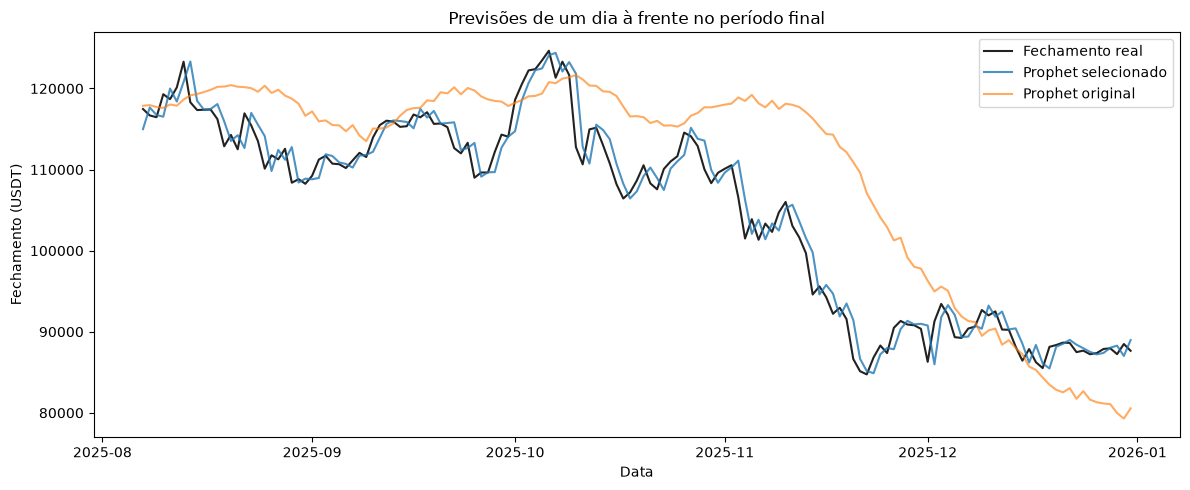

In [4]:
selected_predictions = evaluate(series, range(584, len(series)), selected)
original_predictions = evaluate(series, range(584, len(series)), specs[0])
report = {"selected": metrics(selected_predictions), "original": metrics(original_predictions),
          "baseline": metrics(selected_predictions, "baseline")}
deployed = selected if report["selected"]["mae_usdt"] < report["original"]["mae_usdt"] else specs[0]
comparison = selected_predictions.rename(columns={"prediction": "selected_prediction"})
comparison["original_prediction"] = original_predictions.prediction.to_numpy()
comparison.to_csv(ARTIFACTS / "test_predictions.csv", index=False)
for name, result in report.items():
    log.info("Teste %s: %s", name, result)
log.info("Configuracao a exportar: %s", deployed["name"])
display(pd.DataFrame(report).T.round(2))
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(pd.to_datetime(comparison.date), comparison.actual, label="Fechamento real", color="#222222")
ax.plot(pd.to_datetime(comparison.date), comparison.selected_prediction, label="Prophet selecionado", alpha=.8)
ax.plot(pd.to_datetime(comparison.date), comparison.original_prediction, label="Prophet original", alpha=.65)
ax.set(xlabel="Data", ylabel=f"Fechamento ({quote})", title="Previsões de um dia à frente no período final")
ax.legend()
fig.tight_layout()
fig.savefig(ROOT / "assets/comparacao-modelos.png", dpi=150)
plt.show()


## 4. Exportar o modelo e os metadados

Ajusto a configuração aprovada até o último dia disponível, respeitando sua janela. O Prophet é salvo com a serialização oficial. Metadados registram alvo, último fechamento, data permitida e hashes. Para retorno logarítmico, a API converte a saída em preço por `ultimo_fechamento * exp(retorno_previsto)`.


In [5]:
final_model = fit_model(series, deployed)
model_text = model_to_json(final_model)
(ARTIFACTS / "prophet_model.json").write_text(model_text, encoding="utf-8")
next_date = series.ds.max() + pd.Timedelta(days=1)
next_value = forecast_price(final_model, next_date, series.y.iloc[-1], deployed["target"])
metadata = {
    "model": "Prophet", "prophet_version": prophet.__version__,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "source": source["source"], "symbol": symbol, "quote_currency": quote,
    "period_start": str(series.ds.min().date()), "period_end": str(series.ds.max().date()),
    "total_rows": len(series), "model_train_rows": len(final_model.history),
    "test_rows": len(selected_predictions),
    "validation_blocks": [{"start": str(series.ds.iloc[b.start].date()), "end": str(series.ds.iloc[b.stop-1].date())} for b in blocks],
    "evaluation_method": "walk-forward de um dia; selecao em 3 blocos anteriores ao teste",
    "test_limitation": "periodo final ja consultado em experimentos anteriores",
    "selected_config": selected, "deployed_config": deployed, "test_metrics": report,
    "last_close": float(series.y.iloc[-1]), "forecast_date": str(next_date.date()),
    "example_prediction": round(next_value, 2), "data_sha256": data_hash,
    "model_sha256": hashlib.sha256(model_text.encode("utf-8")).hexdigest(),
}
(ARTIFACTS / "training_metadata.json").write_text(json.dumps(metadata, indent=2, ensure_ascii=False), encoding="utf-8")
log.info("Artefatos exportados; previsao para %s: %.2f %s", next_date.date(), next_value, quote)
log.info("Fim UTC: %s", datetime.now(timezone.utc).isoformat())
handler.flush()
display(metadata)


19:59:06 - cmdstanpy - INFO - Chain [1] start processing


19:59:06 - cmdstanpy - INFO - Chain [1] done processing


Artefatos exportados; previsao para 2026-01-01: 87495.56 USDT


Fim UTC: 2026-10-05T19:59:06.808521+00:00


{'model': 'Prophet',
 'prophet_version': '1.2.2',
 'created_at_utc': '2026-10-05T19:59:06.795719+00:00',
 'source': 'CryptoDataDownload / Binance BTCUSDT (fallback usado após limite de requisições do Yahoo Finance)',
 'symbol': 'BTCUSDT',
 'quote_currency': 'USDT',
 'period_start': '2024-01-01',
 'period_end': '2025-12-31',
 'total_rows': 731,
 'model_train_rows': 730,
 'test_rows': 147,
 'validation_blocks': [{'start': '2024-12-31', 'end': '2025-01-29'},
  {'start': '2025-03-31', 'end': '2025-04-29'},
  {'start': '2025-07-08', 'end': '2025-08-06'}],
 'evaluation_method': 'walk-forward de um dia; selecao em 3 blocos anteriores ao teste',
 'test_limitation': 'periodo final ja consultado em experimentos anteriores',
 'selected_config': {'name': 'retorno_todo_semanalTrue',
  'window': None,
  'target': 'log_return',
  'params': {'growth': 'flat',
   'daily_seasonality': False,
   'weekly_seasonality': True,
   'yearly_seasonality': False}},
 'deployed_config': {'name': 'retorno_todo_seman